# Clinical Alzheimer's Mood Assessment — Speech model **v3 (clinical redesign)**

A WavLM-based mood detector engineered as a *component* of a future Alzheimer's monitoring platform. The objective is **robustness, calibration, generalization, and reliability**, not a benchmark score. Every change is driven by the v2 run (Test acc 0.7237 / macro-F1 0.7173 / balanced 0.7209).

> **Not a medical device.** Trained on *acted* emotional speech; the clinical target (elderly patients, spontaneous speech) is a large, unmeasured domain shift. Real-world performance is unknown until domain-adapted and prospectively validated on patient data. **No configuration here is "perfect" or deployment-ready.**

## A. Technical analysis of the v2 results — what is limiting performance

**The numbers are balanced now** (acc 0.724 ≈ balanced acc 0.721 ≈ macro-F1 0.717): the v1 degenerate-Calm problem is gone. So further gains must come from **separability**, not from fixing class collapse.

**Where the error lives (decomposed from your confusion data):**
- Collapsing the 6 moods onto the **arousal axis** gives **0.887** accuracy vs **0.724** for the 6-way task. That **0.163 gap is the ceiling-defining fact**: the model reads *arousal* (energy/activation) well, but loses ~16 points on *valence and fine distinctions within an arousal band*.
- Of the top-4 error pairs (208 units), **162 are within the same arousal band**: Content→Agitated (73, high-arousal valence flip), Anxious→Agitated (42, high-arousal negative), Low→Neutral (47, low-arousal valence). Only Low→Anxious (46) crosses bands.
- **Recall-limited classes:** Low (R 0.44), Content (R 0.60), Anxious (R 0.63). These are exactly the states whose acoustic signature is *subtle* (sadness) or *valence-defined* (happy vs angry), which prosody underdetermines.
- **Calm F1 0.836 is partly a corpus artifact:** Calm exists only in RAVDESS, so the classifier can lean on RAVDESS recording cues. Strong Calm is the least trustworthy number for clinical transfer.

**Conclusion:** performance is limited by the **information content of the labels and audio**, not by under-training. Voice alone, on *acted* clips, with *perceived-emotion* labels that humans themselves disagree on, does not linearly separate happy/angry or sad/neutral.

## B. Which bottleneck is it? (ranked, with reasoning)

1. **Dataset quality + intrinsic label ambiguity — PRIMARY.** These are *acted* corpora; CREMA-D labels are crowd-sourced *perceived* emotion with substantial rater disagreement (voice-only human agreement on 6-way is well below ceiling). Many clips are genuinely ambiguous, so a chunk of the 0.276 error is **irreducible label noise**, not model error.
2. **Cross-corpus / domain shift — PRIMARY (for the clinical goal).** Corpora differ in mics, scripts, speakers; `Calm` is single-corpus. And the real target — dementia patients' spontaneous speech — is an *unmeasured* shift far larger than anything in train. In-distribution test accuracy **overstates** clinical performance.
3. **Mood taxonomy / class mapping — CONTRIBUTING.** The 6 states sit on overlapping acoustic regions (arousal/valence). Folding disgust→Agitated and mapping happy→Content are defensible but the categories are not acoustically orthogonal. The arousal collapse (0.887) shows a coarser taxonomy is far more reliable.
4. **Label noise — CONTRIBUTING** (same root as #1).
5. **Speaker variation — PARTIALLY ADDRESSED** (speaker-disjoint splits) but train speakers are young actors, not elderly patients.
6. **Model architecture — MINOR.** WavLM-base-plus is strong; `wavlm-large` buys a few points (EmoBox: large ≫ base on CREMA-D) but cannot manufacture valence information that isn't in the signal.
7. **Training strategy — MINOR/DIMINISHING.** v2 already uses focal + balanced sampling + discriminative LR. Squeezing more needs regularization/ensembling, worth a few points at most.

**So: the lever with the most headroom is not a bigger model — it is (a) extracting every bit of valence signal with better representations + augmentation + ensembling/TTA, and (b) reframing the deliverable around clinically-reliable outputs (coarse arousal/distress + calibrated abstention) instead of chasing fine 6-way accuracy.**

## B/C. Improvements, expected gains, and risk/tradeoffs

| Change (this redesign) | Why it targets the bottleneck | Expected gain (valid, cross-speaker) | Risk / tradeoff |
|---|---|---|---|
| **Multi-task head: 6-way mood + auxiliary arousal** | arousal is the reliable signal (0.887); joint training regularizes & yields a trustworthy coarse output for triage | +0.5–1.5 pt macro-F1; **big clinical value** (reliable coarse output) | small extra complexity |
| **Class-balanced focal loss** (effective-number weights × focal) | principled rare-class handling without v1's 20× flood; focal = soft **hard-example mining** | +0–1 pt; steadier minority recall | β,γ tuning |
| **Domain-shift augmentation** (noise, gain, mild pitch/stretch, **band-pass/telephony, reverb**) | simulates real mics/rooms/phones → cross-corpus + clinical robustness | small in-dist gain; **larger out-of-dist robustness** | pitch/tempo carry emotion → kept mild; CPU cost |
| **Curriculum (augmentation intensity ramp)** | stabilize early training, harden later | minor; smoother convergence | longer schedule |
| **Supervised contrastive aux loss (metric learning)** | pulls same-mood embeddings together → better valence separation & transfer | +0–1.5 pt; better embeddings | needs batch positives; small λ; can add variance |
| **MixUp (audio input)** *(optional)* | label-smoothing-like regularizer → calibration & generalization | +0–1 pt; better ECE | interacts with imbalance; off by default |
| **TTA + multi-sample voting** | average over augmented views → variance reduction, **more reliable single decisions** | +0.5–1.5 pt; **steadier predictions** | ~N× inference cost |
| **Temperature calibration + ECE + reliability** | clinical decisions need trustworthy probabilities | calibration, not accuracy | fit on val only |
| **Confidence threshold / abstention** | route uncertain cases to a clinician | accuracy↑ on covered set | lower coverage |
| **Per-corpus + leave-one-corpus-out (LOCO) eval** | honest generalization measurement | none to score — it *reveals* shift | LOCO retrain is slower |
| **Ensemble-ready (multi-seed + averaging loader + manifest)** | averaging seeds reduces variance & improves calibration | +0.5–1.5 pt with 3–5 seeds | N× training time |
| **Pseudo-labeling hook for unlabeled clinical audio** | the *correct* path to domain-adapt to patients (semi-supervised) | unlocks clinical transfer (needs patient data) | off by default; needs unlabeled data |
| **WavLM-large switch** | more capacity/better SER pretraining | +1–3 pt | ~3× memory/time |

All model-selection, calibration, and threshold choices use **val only**; **test is read once**.

## D-feasibility. Can this exceed 75 / 80 / 85%? (honest)

These thresholds must be read as **speaker-disjoint** (and ideally **corpus-disjoint**) 6-way accuracy on *acted* data — not random-split numbers (random splits leak speakers and easily show inflated 90%+).

- **75%** — *Realistic.* Multi-task + CB-focal + TTA + a 3-seed ensemble, especially with `wavlm-large`, should reach the mid-to-high 70s on the combined speaker-disjoint set.
- **80%** — *Possible but near the valid ceiling.* Achievable mainly because TESS (2 speakers, near-trivial) and clean acted prototypes inflate the average; on a strict **leave-one-corpus-out** test it will be lower. Treat 80% as the optimistic edge of *valid* 6-way performance, not a target to force.
- **85%** — *Not realistically achievable for scientifically-valid 6-way cross-speaker/cross-corpus on these datasets.* It exceeds plausible human voice-only agreement on this label set; reaching it almost always indicates **leakage** (speaker/corpus) or TESS dominance. **Do not claim it.**
- **Where 85%+ is both attainable and more useful:** the **coarse clinical outputs** — arousal (already 0.887) or a binary **distress vs non-distress** head. For a monitoring platform, "is this person distressed/agitated right now, and how confident are we?" is more actionable *and* more reliable than a fine 6-way label. v3 produces both.

**Most important caveat:** every number above is on acted speech. Expect **substantially lower** performance on real dementia patients until the model is domain-adapted (pseudo-labeling hook + clinician-labeled patient data) and prospectively validated.

## 1. Environment & dependencies

In [ ]:
import sys, subprocess
def _pip(pkgs):
    try: subprocess.check_call([sys.executable,"-m","pip","install","-q"]+pkgs)
    except Exception as e: print("pip warning:", e)
_pip(["transformers>=4.40.0","librosa>=0.10.0","soundfile>=0.12.1","scikit-learn>=1.3.0","kagglehub>=0.2.0"])
print("deps ok")

deps ok


In [ ]:
import os, gc, json, random, glob, re, warnings, zipfile, math, shutil
from pathlib import Path
from dataclasses import dataclass, field, asdict
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import librosa, soundfile as sf
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split
import transformers
from transformers import AutoFeatureExtractor, WavLMModel, get_cosine_schedule_with_warmup
os.environ.setdefault("TOKENIZERS_PARALLELISM","false"); warnings.filterwarnings("ignore")
print("torch", torch.__version__, "| transformers", transformers.__version__)

torch 2.11.0+cu128 | transformers 5.10.1


## 2. Hardware

In [ ]:
CUDA = torch.cuda.is_available(); N_GPU = torch.cuda.device_count() if CUDA else 0
DEVICE = torch.device("cuda" if CUDA else "cpu"); USE_DP = N_GPU > 1
print("CUDA", CUDA, "| GPUs", N_GPU, "| device", DEVICE, "| DataParallel", USE_DP)
if CUDA:
    for i in range(N_GPU):
        p = torch.cuda.get_device_properties(i); print(f"  [GPU {i}] {p.name} {p.total_memory/1e9:.1f}GB")
    torch.backends.cudnn.benchmark = True

CUDA True | GPUs 1 | device cuda | DataParallel False
  [GPU 0] Tesla T4 15.6GB


## 3. Seeds

In [ ]:
def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed(42); print("seed 42")

seed 42


## 4. Configuration — all clinical-redesign levers

In [ ]:
@dataclass
class Config:
    model_name: str = "microsoft/wavlm-base-plus"   # -> "microsoft/wavlm-large" for +1-3pt
    sample_rate: int = 16000
    max_duration_sec: float = 6.0
    # SpecAugment (native, train only)
    mask_time_prob: float = 0.08
    mask_feature_prob: float = 0.05
    dropout: float = 0.1
    # multi-task
    use_arousal_head: bool = True
    lambda_arousal: float = 0.3
    # metric learning (supervised contrastive) — auxiliary
    lambda_supcon: float = 0.05
    supcon_temp: float = 0.1
    # mixup (optional; off by default — interacts with imbalance)
    use_mixup: bool = False
    mixup_alpha: float = 0.4
    mixup_prob: float = 0.5
    # loss / balancing
    focal_gamma: float = 1.5
    label_smoothing: float = 0.05
    cb_beta: float = 0.999                  # class-balanced (effective number) weights
    sampler_temp: float = 0.5               # tempered weighted sampler (lighter now CB weights exist)
    corpus_aware_sampler: bool = True
    # optimization
    epochs: int = 12
    batch_size: int = 16
    lr_head: float = 1e-3
    lr_encoder: float = 2e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    grad_clip: float = 1.0
    num_workers: int = 2
    freeze_encoder_epochs: int = 1
    early_stop_patience: int = 3
    # augmentation + curriculum
    use_augmentation: bool = True
    curriculum_epochs: int = 3              # ramp aug intensity over first N epochs
    aug_noise_prob: float = 0.5
    aug_gain_prob: float = 0.5
    aug_pitch_prob: float = 0.3
    aug_pitch_max_steps: float = 2.0
    aug_stretch_prob: float = 0.3
    aug_telephony_prob: float = 0.25        # band-pass 300-3400 Hz (phone)
    aug_reverb_prob: float = 0.2
    # TTA
    use_tta: bool = True
    tta_views: int = 5
    # cross-corpus
    holdout_corpus: str = ""                # e.g. "SAVEE" for leave-one-corpus-out; "" disables
    val_frac: float = 0.15
    test_frac: float = 0.15
    merge_calm_into_neutral: bool = False
    # ensemble
    seeds: tuple = (42,)                    # add more, e.g. (42,7,123), for an ensemble
    # semi-supervised (clinical domain adaptation) — optional
    pseudo_label_dir: str = ""              # path to UNLABELED audio for pseudo-labeling
    pseudo_label_conf: float = 0.9
    # data acquisition
    kaggle_input_root: str = "/kaggle/input"
    try_kagglehub_download: bool = True
    allow_smoke_test: bool = True
    smoke_clips_per_class: int = 60
    output_dir: str = "outputs"
    seed: int = 42

CFG = Config()
MAX_SAMPLES = int(CFG.max_duration_sec*CFG.sample_rate)
os.makedirs(CFG.output_dir, exist_ok=True)
print("model:", CFG.model_name, "| arousal_head:", CFG.use_arousal_head,
      "| supcon:", CFG.lambda_supcon, "| mixup:", CFG.use_mixup, "| TTA:", CFG.use_tta,
      "| holdout_corpus:", repr(CFG.holdout_corpus), "| seeds:", CFG.seeds)

model: microsoft/wavlm-base-plus | arousal_head: True | supcon: 0.05 | mixup: False | TTA: True | holdout_corpus: '' | seeds: (42,)


## 5. Taxonomy + arousal axis (clinical coarse signal)

In [ ]:
EMOTION_TO_MOOD = {"neutral":"Neutral","calm":"Calm","happy":"Content","sad":"Low",
                   "angry":"Agitated","disgust":"Agitated","fearful":"Anxious","surprised":None}
MOOD_AROUSAL = {"Calm":"low","Neutral":"low","Low":"low","Content":"high","Anxious":"high","Agitated":"high"}
AROUSAL2ID = {"low":0,"high":1}
MOOD_STATES = ["Calm","Neutral","Content","Anxious","Agitated","Low"]
def emotion_to_mood(e):
    m = EMOTION_TO_MOOD.get(e)
    return "Neutral" if (m=="Calm" and CFG.merge_calm_into_neutral) else m
print("moods:", MOOD_STATES, "| arousal:", MOOD_AROUSAL)

moods: ['Calm', 'Neutral', 'Content', 'Anxious', 'Agitated', 'Low'] | arousal: {'Calm': 'low', 'Neutral': 'low', 'Low': 'low', 'Content': 'high', 'Anxious': 'high', 'Agitated': 'high'}


## 6. Dataset acquisition

In [ ]:
def find_wavs(root):
    root = Path(root)
    if not root.exists(): return []
    f = []
    for e in ("*.wav","*.WAV","*.flac","*.mp3"): f.extend(root.rglob(e))
    return f
audio_files = find_wavs(CFG.kaggle_input_root)
print("found", len(audio_files), "files under", CFG.kaggle_input_root)
if not audio_files and CFG.try_kagglehub_download:
    try:
        import kagglehub
        dl = kagglehub.dataset_download("dmitrybabko/speech-emotion-recognition-en")
        audio_files = find_wavs(dl); print("kagglehub:", len(audio_files), "from", dl)
    except Exception as e: print("kagglehub failed:", e)
print("TOTAL", len(audio_files))

found 0 files under /kaggle/input
Using Colab cache for faster access to the 'speech-emotion-recognition-en' dataset.
kagglehub: 12162 from /kaggle/input/speech-emotion-recognition-en
TOTAL 12162


## 7. Label parsing

In [ ]:
RAVDESS_EMO={"01":"neutral","02":"calm","03":"happy","04":"sad","05":"angry","06":"fearful","07":"disgust","08":"surprised"}
CREMA_EMO={"ANG":"angry","DIS":"disgust","FEA":"fearful","HAP":"happy","NEU":"neutral","SAD":"sad"}
SAVEE_EMO={"a":"angry","d":"disgust","f":"fearful","h":"happy","n":"neutral","sa":"sad","su":"surprised"}
def parse_ravdess(p):
    s=Path(p).stem.split("-")
    return (RAVDESS_EMO[s[2]], f"RAVDESS_actor{s[6]}") if len(s)==7 and s[2] in RAVDESS_EMO else (None,None)
def parse_crema(p):
    s=Path(p).stem.split("_")
    return (CREMA_EMO[s[2].upper()], f"CREMA_{s[0]}") if len(s)>=3 and s[2].upper() in CREMA_EMO else (None,None)
def parse_tess(p):
    s=Path(p).stem.lower()
    spk="TESS_OAF" if s.startswith("oaf") else ("TESS_YAF" if s.startswith("yaf") else None)
    if spk is None and "tess" not in str(p).lower(): return (None,None)
    spk=spk or "TESS_unk"
    if "pleasant" in s or s.endswith("_ps") or "surprise" in s: return ("surprised",spk)
    for k,e in [("neutral","neutral"),("happy","happy"),("sad","sad"),("angry","angry"),("fear","fearful"),("disgust","disgust")]:
        if k in s: return (e,spk)
    return (None,None)
def parse_savee(p):
    m=re.match(r"^([A-Za-z]{2})_([a-z]{1,2})\d+$", Path(p).stem)
    return (SAVEE_EMO[m.group(2)], f"SAVEE_{m.group(1)}") if m and m.group(2) in SAVEE_EMO else (None,None)
def parse_any(p):
    s=str(p).lower(); order=[]
    if "ravdess" in s or "actor_" in s: order.append(parse_ravdess)
    if "crema" in s or "audiowav" in s: order.append(parse_crema)
    if "tess" in s: order.append(parse_tess)
    if "savee" in s: order.append(parse_savee)
    for fn in (parse_ravdess,parse_crema,parse_tess,parse_savee):
        if fn not in order: order.append(fn)
    for fn in order:
        e,spk=fn(p)
        if e is not None: return e,spk,fn.__name__.replace("parse_","")
    return None,None,None
rows=[]
for f in audio_files:
    e,spk,src=parse_any(f)
    if e is None: continue
    mood=emotion_to_mood(e)
    if mood is None: continue
    rows.append({"path":str(f),"emotion":e,"mood":mood,"group":spk,"corpus":src})
df=pd.DataFrame(rows); print("parsed", len(df))
if len(df): print(df.groupby(["corpus","mood"]).size().unstack(fill_value=0))

parsed 11510
mood     Agitated  Anxious  Calm  Content   Low  Neutral
corpus                                                  
crema        2542     1271     0     1271  1271     1087
ravdess       384      192   192      192   192       96
savee         120       60     0       60    60      120
tess          800      400     0      400   400      400


## 8. Synthetic smoke-test fallback (artifacts NOT clinically valid)

In [ ]:
SMOKE=False
if len(df)==0:
    if not CFG.allow_smoke_test: raise RuntimeError("No data; attach 'dmitrybabko/speech-emotion-recognition-en'.")
    SMOKE=True; print("!!! SYNTHETIC SMOKE TEST — pipeline validation only !!!")
    sd=Path("synthetic_audio"); sd.mkdir(exist_ok=True); sr=CFG.sample_rate
    rng=np.random.default_rng(42); rows=[]; base={m:150+55*i for i,m in enumerate(MOOD_STATES)}
    for m in MOOD_STATES:
        for k in range(CFG.smoke_clips_per_class):
            t=np.linspace(0,2.0,int(sr*2.0),endpoint=False); f0=base[m]*(1+0.03*rng.standard_normal())
            w=0.3*np.sin(2*np.pi*f0*t)+0.15*np.sin(2*np.pi*2*f0*t)+0.05*rng.standard_normal(t.shape[0])
            w=(w/np.max(np.abs(w)+1e-9)).astype(np.float32); fp=sd/f"synth_{m}_{k}.wav"; sf.write(fp,w,sr)
            rows.append({"path":str(fp),"emotion":"synthetic","mood":m,"group":f"SYNTH_spk{k%10}","corpus":"synthetic"})
    df=pd.DataFrame(rows); CFG.epochs=3; CFG.freeze_encoder_epochs=0; CFG.tta_views=2; CFG.curriculum_epochs=1
    print("synthetic", len(df))

classes: {'Calm': 0, 'Neutral': 1, 'Content': 2, 'Anxious': 3, 'Agitated': 4, 'Low': 5} | clips: 11510 | speakers: 122


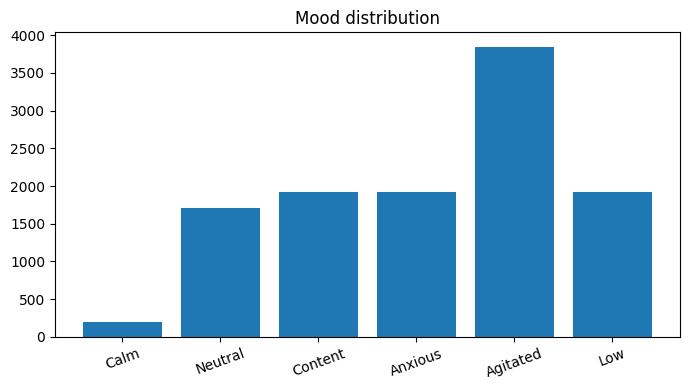

In [ ]:
def readable(p):
    try: return sf.info(p).frames>0
    except Exception:
        try: y,_=librosa.load(p,sr=None,duration=0.3); return y.size>0
        except Exception: return False
chk = df.index if len(df)<=2000 else df.sample(2000,random_state=42).index
bad=[i for i in chk if not readable(df.loc[i,"path"])]
if bad: df=df.drop(index=bad).reset_index(drop=True); print("dropped",len(bad))
present=[m for m in MOOD_STATES if m in set(df["mood"])]
label2id={m:i for i,m in enumerate(present)}; id2label={i:m for m,i in label2id.items()}
df["label_id"]=df["mood"].map(label2id)
df["arousal_id"]=df["mood"].map(lambda m: AROUSAL2ID[MOOD_AROUSAL[m]])
NUM_CLASSES=len(label2id); NUM_AROUSAL=2
print("classes:", label2id, "| clips:", len(df), "| speakers:", df["group"].nunique())
plt.figure(figsize=(7,4)); c=df["mood"].value_counts().reindex(present)
plt.bar(c.index,c.values); plt.title("Mood distribution"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 9. Split — per-corpus speaker-grouped, with optional leave-one-corpus-out (LOCO)

Set `holdout_corpus` to e.g. `"SAVEE"` to train on the other corpora and test entirely on the held-out one — the **honest cross-corpus generalization** measure (expect lower, more realistic numbers).

In [ ]:
def per_corpus_speaker_split(df, seed=42, val_frac=0.15, test_frac=0.15, holdout=""):
    rng=np.random.default_rng(seed); assign={}
    if holdout and holdout in set(df["corpus"]):
        for s in df[df["corpus"]==holdout]["group"].unique(): assign[s]="test"
        sub=df[df["corpus"]!=holdout]
    else:
        sub=df
    for corpus,g in sub.groupby("corpus"):
        spk=list(g["group"].unique()); rng.shuffle(spk); n=len(spk)
        if n==1: tr,va,te=spk,[],[]
        elif n==2: tr,va,te=[spk[0]],[],[spk[1]]
        elif n==3: tr,va,te=[spk[0]],[spk[1]],[spk[2]]
        else:
            nte=max(1,int(round(test_frac*n))); nva=max(1,int(round(val_frac*n)))
            if nte+nva>=n: nte,nva=1,1
            te,va,tr=spk[:nte],spk[nte:nte+nva],spk[nte+nva:]
        if holdout and holdout in set(df["corpus"]):
            te=[]  # all test comes from the held-out corpus
        for s in tr: assign[s]="train"
        for s in va: assign[s]="val"
        for s in te: assign[s]="test"
    sp=df["group"].map(assign)
    return (df[sp=="train"].reset_index(drop=True), df[sp=="val"].reset_index(drop=True),
            df[sp=="test"].reset_index(drop=True))

train_df,val_df,test_df = per_corpus_speaker_split(df,42,CFG.val_frac,CFG.test_frac,CFG.holdout_corpus)
if len(val_df)==0 or len(test_df)==0:
    print("fallback stratified split")
    tv,test_df=train_test_split(df,test_size=CFG.test_frac,random_state=42,stratify=df["label_id"])
    train_df,val_df=train_test_split(tv,test_size=CFG.val_frac/(1-CFG.test_frac),random_state=42,stratify=tv["label_id"])
    train_df,val_df,test_df=[d.reset_index(drop=True) for d in (train_df,val_df,test_df)]
ov=(set(train_df.group)&set(val_df.group))|(set(train_df.group)&set(test_df.group))|(set(val_df.group)&set(test_df.group))
print(f"Train {len(train_df)} | Val {len(val_df)} ({len(val_df)/len(df):.1%}) | Test {len(test_df)} ({len(test_df)/len(df):.1%})")
print("speaker overlap:", len(ov), "| holdout_corpus:", repr(CFG.holdout_corpus))
print("Val moods:", dict(val_df.mood.value_counts()), "\nTest moods:", dict(test_df.mood.value_counts()))

Train 7387 | Val 2661 (23.1%) | Test 1462 (12.7%)
speaker overlap: 0 | holdout_corpus: ''
Val moods: {'Agitated': np.int64(886), 'Content': np.int64(443), 'Anxious': np.int64(443), 'Low': np.int64(443), 'Neutral': np.int64(414), 'Calm': np.int64(32)} 
Test moods: {'Agitated': np.int64(486), 'Low': np.int64(243), 'Content': np.int64(243), 'Anxious': np.int64(243), 'Neutral': np.int64(215), 'Calm': np.int64(32)}


## 10. Domain-shift augmentation (train only; curriculum-annealed)

Beyond noise/gain/pitch/stretch, we add **band-pass telephony** (300–3400 Hz) and **reverb** to simulate phones and rooms — the conditions a real monitoring device faces. Intensity ramps over the first epochs (curriculum).

In [ ]:
def _bandpass(y, sr, lo=300, hi=3400):
    Y=np.fft.rfft(y); fr=np.fft.rfftfreq(len(y),1.0/sr)
    Y[(fr<lo)|(fr>hi)]=0
    return np.fft.irfft(Y, n=len(y)).astype(np.float32)
def _reverb(y, sr, rng):
    decay=float(rng.uniform(0.2,0.5)); n=int(sr*decay)
    ir=np.exp(-np.linspace(0,6,max(n,1))).astype(np.float32); ir[0]=1.0
    out=np.convolve(y,ir)[:len(y)]
    m=np.max(np.abs(out))+1e-9
    return (out/m).astype(np.float32)
def augment_waveform(y, sr, cfg, rng, scale=1.0):
    if rng.random() < cfg.aug_stretch_prob*scale:
        try: y=librosa.effects.time_stretch(y, rate=float(rng.uniform(0.9,1.1)))
        except Exception: pass
    if rng.random() < cfg.aug_pitch_prob*scale:
        try: y=librosa.effects.pitch_shift(y, sr=sr, n_steps=float(rng.uniform(-cfg.aug_pitch_max_steps,cfg.aug_pitch_max_steps)))
        except Exception: pass
    if rng.random() < cfg.aug_reverb_prob*scale:
        y=_reverb(y,sr,rng)
    if rng.random() < cfg.aug_telephony_prob*scale:
        y=_bandpass(y,sr)
    if rng.random() < cfg.aug_noise_prob*scale:
        snr=float(rng.uniform(15,30)); sp=np.mean(y**2)+1e-12; npw=sp/(10**(snr/10))
        y=y+np.sqrt(npw)*rng.standard_normal(y.shape).astype(np.float32)
    if rng.random() < cfg.aug_gain_prob*scale:
        y=y*float(10**(rng.uniform(-6,6)/20))
    m=np.max(np.abs(y))+1e-9
    if m>1.0: y=y/m
    return y.astype(np.float32)
print("augmentation ready (noise/gain/pitch/stretch/telephony/reverb)")

augmentation ready (noise/gain/pitch/stretch/telephony/reverb)


## 11. Dataset, collation, sampler

In [ ]:
feature_extractor = AutoFeatureExtractor.from_pretrained(CFG.model_name)
print("feature extractor:", feature_extractor.__class__.__name__)

class MoodDataset(Dataset):
    def __init__(self, frame, cfg, train=False):
        self.paths=frame["path"].tolist(); self.y=frame["label_id"].tolist(); self.ar=frame["arousal_id"].tolist()
        self.cfg=cfg; self.train=train; self.sr=cfg.sample_rate
        self.max_samples=int(cfg.max_duration_sec*cfg.sample_rate)
        self.base_seed=cfg.seed; self.aug_offset=0; self.aug_scale=1.0
    def __len__(self): return len(self.paths)
    def set_epoch(self, e):
        self.aug_offset=e
        self.aug_scale=min(1.0,(e+1)/max(1,self.cfg.curriculum_epochs)) if self.cfg.curriculum_epochs>0 else 1.0
    def __getitem__(self,i):
        try: y,_=librosa.load(self.paths[i],sr=self.sr,mono=True)
        except Exception: y=np.zeros(self.sr,dtype=np.float32)
        if y.size==0: y=np.zeros(self.sr,dtype=np.float32)
        if self.train and self.cfg.use_augmentation:
            rng=np.random.default_rng(self.base_seed + self.aug_offset*100003 + i)
            y=augment_waveform(y,self.sr,self.cfg,rng,self.aug_scale)
        if len(y)>self.max_samples: y=y[:self.max_samples]
        return {"array":y.astype(np.float32),"label":int(self.y[i]),"arousal":int(self.ar[i])}

def collate_fn(batch):
    arrays=[b["array"] for b in batch]
    labels=torch.tensor([b["label"] for b in batch],dtype=torch.long)
    arousal=torch.tensor([b["arousal"] for b in batch],dtype=torch.long)
    feats=feature_extractor(arrays,sampling_rate=CFG.sample_rate,return_tensors="pt",
                            padding="longest",max_length=MAX_SAMPLES,truncation=True)
    out={"input_values":feats["input_values"],"labels":labels,"arousal":arousal}
    if "attention_mask" in feats: out["attention_mask"]=feats["attention_mask"]
    return out

def build_sampler(frame,cfg):
    labels=frame["label_id"].values; cc=np.bincount(labels,minlength=NUM_CLASSES).astype(np.float64)
    w=((1.0/np.maximum(cc,1.0))**cfg.sampler_temp)[labels]
    if cfg.corpus_aware_sampler and frame["corpus"].nunique()>1:
        corp=frame["corpus"].value_counts().to_dict()
        w=w*frame["corpus"].map(lambda c:(1.0/corp[c])**(cfg.sampler_temp*0.5)).values
    w=w/w.sum()
    return WeightedRandomSampler(torch.as_tensor(w,dtype=torch.double),len(frame),replacement=True)

train_ds=MoodDataset(train_df,CFG,train=True); val_ds=MoodDataset(val_df,CFG,False); test_ds=MoodDataset(test_df,CFG,False)
pin=CUDA
train_loader=DataLoader(train_ds,batch_size=CFG.batch_size,sampler=build_sampler(train_df,CFG),
                        num_workers=CFG.num_workers,collate_fn=collate_fn,pin_memory=pin)
val_loader=DataLoader(val_ds,batch_size=CFG.batch_size,shuffle=False,num_workers=CFG.num_workers,collate_fn=collate_fn,pin_memory=pin)
test_loader=DataLoader(test_ds,batch_size=CFG.batch_size,shuffle=False,num_workers=CFG.num_workers,collate_fn=collate_fn,pin_memory=pin)
print("batch:", tuple(next(iter(train_loader))["input_values"].shape))

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

feature extractor: Wav2Vec2FeatureExtractor
batch: (16, 57658)


## 12. Model — multi-task WavLM (mood + arousal heads, attentive masked pooling)

A custom head structure (vs the single-head v2 model) so we can train the **reliable arousal axis** jointly and expose pooled embeddings for **metric learning**.

In [ ]:
class AttentiveMaskedPool(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.attn=nn.Linear(dim,1)
    def forward(self, h, mask):  # h (B,T,H), mask (B,T)
        s=self.attn(h).squeeze(-1)
        s=s.masked_fill(mask==0, float("-inf"))
        w=torch.softmax(s,dim=1).unsqueeze(-1)
        return (h*w).sum(1)

class MultiTaskMoodModel(nn.Module):
    def __init__(self, model_name, num_moods, num_arousal=2, dropout=0.1,
                 mask_time_prob=0.08, mask_feature_prob=0.05):
        super().__init__()
        self.backbone=WavLMModel.from_pretrained(model_name)
        self.backbone.config.apply_spec_augment=True
        self.backbone.config.mask_time_prob=mask_time_prob
        self.backbone.config.mask_feature_prob=mask_feature_prob
        for a,d in [("mask_time_min_masks",2),("mask_feature_min_masks",0)]:
            if not hasattr(self.backbone.config,a): setattr(self.backbone.config,a,d)
        self.backbone.freeze_feature_encoder()
        h=self.backbone.config.hidden_size
        self.pool=AttentiveMaskedPool(h); self.drop=nn.Dropout(dropout)
        self.mood_head=nn.Sequential(nn.Linear(h,h),nn.GELU(),nn.Dropout(dropout),nn.Linear(h,num_moods))
        self.arousal_head=nn.Linear(h,num_arousal)
    def _feat_mask(self, attn, T, device):
        if attn is None: return torch.ones(1,T,device=device)
        try: lengths=self.backbone._get_feat_extract_output_lengths(attn.sum(-1)).long()
        except Exception: return torch.ones(attn.size(0),T,device=device)
        idx=torch.arange(T,device=device)[None,:]
        return (idx<lengths[:,None]).long()
    def forward(self, input_values, attention_mask=None):
        out=self.backbone(input_values, attention_mask=attention_mask)
        h=out.last_hidden_state
        m=self._feat_mask(attention_mask, h.size(1), h.device)
        if m.size(0)==1 and h.size(0)>1: m=m.expand(h.size(0),-1)
        pooled=self.drop(self.pool(h,m))
        return self.mood_head(pooled), self.arousal_head(pooled), pooled

def build_model(seed=42):
    set_seed(seed)
    m=MultiTaskMoodModel(CFG.model_name,NUM_CLASSES,NUM_AROUSAL,CFG.dropout,CFG.mask_time_prob,CFG.mask_feature_prob).to(DEVICE)
    return nn.DataParallel(m) if USE_DP else m
def unwrap(m): return m.module if isinstance(m,nn.DataParallel) else m
def param_groups(model):
    head,enc=[],[]
    for n,p in unwrap(model).named_parameters():
        if "backbone.feature_extractor" in n: p.requires_grad_(False); continue
        (enc if n.startswith("backbone.") else head).append(p)
    return head,enc
print("model class ready (multi-task WavLM)")

model class ready (multi-task WavLM)


## 13. Losses — class-balanced focal + arousal CE + supervised contrastive (+ MixUp path)

In [ ]:
def effective_num_weights(frame, beta=0.999):
    cc=np.bincount(frame["label_id"].values,minlength=NUM_CLASSES).astype(np.float64)
    eff=(1.0-np.power(beta,cc))/(1.0-beta); w=1.0/np.maximum(eff,1e-8); w=w/w.sum()*NUM_CLASSES
    return torch.tensor(w,dtype=torch.float32,device=DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, weight=None, label_smoothing=0.0):
        super().__init__(); self.g=gamma; self.w=weight; self.ls=label_smoothing
    def forward(self, logits, target):
        logp=F.log_softmax(logits,dim=-1); p=logp.exp()
        logp_t=logp.gather(1,target.unsqueeze(1)).squeeze(1); p_t=p.gather(1,target.unsqueeze(1)).squeeze(1)
        ce = -((1-self.ls)*logp_t + self.ls*logp.mean(1)) if self.ls>0 else -logp_t
        loss=((1-p_t)**self.g)*ce
        if self.w is not None: loss=loss*self.w.gather(0,target)
        return loss.mean()

class SupConLoss(nn.Module):
    def __init__(self, temp=0.1): super().__init__(); self.t=temp
    def forward(self, feats, labels):
        f=F.normalize(feats,dim=1); B=f.size(0)
        sim=(f@f.T)/self.t
        sim=sim-sim.max(1,keepdim=True).values.detach()
        self_mask=~torch.eye(B,dtype=torch.bool,device=f.device)
        pos=(labels[:,None]==labels[None,:])&self_mask
        exp=torch.exp(sim)*self_mask
        logp=sim-torch.log(exp.sum(1,keepdim=True)+1e-12)
        denom=pos.sum(1)
        mlp=(pos*logp).sum(1)/denom.clamp(min=1)
        valid=denom>0
        return (-mlp[valid].mean()) if valid.any() else feats.sum()*0.0

def soft_ce(logits, ya, yb, lam):
    logp=F.log_softmax(logits,dim=-1)
    return -(lam*logp.gather(1,ya[:,None]).squeeze(1)+(1-lam)*logp.gather(1,yb[:,None]).squeeze(1)).mean()

def mixup_inputs(x, alpha):
    lam=float(np.random.beta(alpha,alpha)); perm=torch.randperm(x.size(0),device=x.device)
    return lam*x+(1-lam)*x[perm], perm, lam

cb_weights=effective_num_weights(train_df,CFG.cb_beta)
print("class-balanced weights:", {id2label[i]:round(float(w),3) for i,w in enumerate(cb_weights)})
focal=FocalLoss(CFG.focal_gamma, cb_weights, CFG.label_smoothing)
ce_arousal=nn.CrossEntropyLoss(label_smoothing=CFG.label_smoothing)
supcon=SupConLoss(CFG.supcon_temp)

class-balanced weights: {'Calm': 3.294, 'Neutral': 0.601, 'Content': 0.558, 'Anxious': 0.558, 'Agitated': 0.432, 'Low': 0.558}


## 14. Training (multi-task, curriculum, optional MixUp/SupCon, progressive unfreeze, early stop)

Trains one model per seed in `CFG.seeds` (ensemble). Selection on **val macro-F1**; test untouched.

In [ ]:
from torch.cuda.amp import autocast, GradScaler

def forward_batch(model, batch):
    inp={"input_values":batch["input_values"].to(DEVICE,non_blocking=True)}
    if "attention_mask" in batch: inp["attention_mask"]=batch["attention_mask"].to(DEVICE,non_blocking=True)
    y=batch["labels"].to(DEVICE,non_blocking=True); ar=batch["arousal"].to(DEVICE,non_blocking=True)
    return inp,y,ar

def save_ckpt(path, model, epoch, val_f1, seed, temperature=1.0):
    torch.save({"model_state_dict":unwrap(model).state_dict(),"model_name":CFG.model_name,
                "label2id":label2id,"id2label":id2label,"num_classes":NUM_CLASSES,"num_arousal":NUM_AROUSAL,
                "mood_arousal":MOOD_AROUSAL,"sample_rate":CFG.sample_rate,"max_samples":MAX_SAMPLES,
                "dropout":CFG.dropout,"epoch":epoch,"val_macro_f1":val_f1,"seed":seed,"temperature":temperature}, path)

def evaluate(model, loader):
    model.eval(); P,Y=[],[]
    with torch.no_grad():
        for batch in loader:
            inp,y,ar=forward_batch(model,batch)
            with autocast(enabled=CUDA):
                ml,_,_=model(**inp)
            P+=ml.argmax(-1).cpu().tolist(); Y+=y.cpu().tolist()
    return f1_score(Y,P,average="macro",zero_division=0)

def train_one(seed):
    model=build_model(seed)
    head,enc=param_groups(model)
    opt=torch.optim.AdamW([{"params":head,"lr":CFG.lr_head,"weight_decay":CFG.weight_decay},
                           {"params":enc,"lr":CFG.lr_encoder,"weight_decay":CFG.weight_decay}])
    total=max(1,len(train_loader)*CFG.epochs)
    sched=get_cosine_schedule_with_warmup(opt,int(CFG.warmup_ratio*total),total)
    scaler=GradScaler(enabled=CUDA)
    def set_enc(flag):
        for p in enc: p.requires_grad_(flag)
    set_enc(CFG.freeze_encoder_epochs<=0)
    best=-1.0; pat=0; hist=[]
    bpath=os.path.join(CFG.output_dir,f"best_seed{seed}.pt")
    for epoch in range(1,CFG.epochs+1):
        if epoch==CFG.freeze_encoder_epochs+1 and CFG.freeze_encoder_epochs>0:
            set_enc(True); print(f"  [seed {seed}][epoch {epoch}] encoder unfrozen")
        train_ds.set_epoch(epoch-1)
        model.train(); tl=0.0; nb=0
        for batch in train_loader:
            inp,y,ar=forward_batch(model,batch); opt.zero_grad(set_to_none=True)
            do_mix=CFG.use_mixup and (np.random.rand()<CFG.mixup_prob)
            with autocast(enabled=CUDA):
                if do_mix:
                    xm,perm,lam=mixup_inputs(inp["input_values"],CFG.mixup_alpha)
                    inp2=dict(inp); inp2["input_values"]=xm
                    if "attention_mask" in inp2:
                        inp2["attention_mask"]=torch.maximum(inp2["attention_mask"],inp2["attention_mask"][perm])
                    ml,al,pooled=model(**inp2)
                    loss=soft_ce(ml,y,y[perm],lam)
                    if CFG.use_arousal_head: loss=loss+CFG.lambda_arousal*soft_ce(al,ar,ar[perm],lam)
                else:
                    ml,al,pooled=model(**inp)
                    loss=focal(ml,y)
                    if CFG.use_arousal_head: loss=loss+CFG.lambda_arousal*ce_arousal(al,ar)
                    if CFG.lambda_supcon>0: loss=loss+CFG.lambda_supcon*supcon(pooled,y)
            scaler.scale(loss).backward(); scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_([p for p in head+enc if p.requires_grad],CFG.grad_clip)
            scaler.step(opt); scaler.update(); sched.step()
            tl+=loss.item(); nb+=1
        vf1=evaluate(model,val_loader)
        hist.append({"epoch":epoch,"train_loss":tl/max(1,nb),"val_f1":vf1})
        print(f"  [seed {seed}] epoch {epoch:02d}/{CFG.epochs} train_loss {tl/max(1,nb):.4f} val_f1 {vf1:.4f}")
        if vf1>best:
            best=vf1; pat=0; save_ckpt(bpath,model,epoch,vf1,seed)
        else:
            pat+=1
            if pat>=CFG.early_stop_patience: print(f"  [seed {seed}] early stop"); break
    return model,bpath,best,hist

ensemble=[]; all_hist={}
for s in CFG.seeds:
    print(f"=== training seed {s} ===")
    mdl,bp,bf1,hist=train_one(s)
    ensemble.append({"seed":s,"path":bp,"val_f1":bf1}); all_hist[s]=hist
    # keep the last trained model object around for export/inference
    model=mdl
ensemble=sorted(ensemble,key=lambda d:d["val_f1"],reverse=True)
print("ensemble:", [(e["seed"],round(e["val_f1"],4)) for e in ensemble])

=== training seed 42 ===


config.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

  [seed 42] epoch 01/12 train_loss 1.0427 val_f1 0.2889
  [seed 42][epoch 2] encoder unfrozen
  [seed 42] epoch 02/12 train_loss 0.6238 val_f1 0.6807
  [seed 42] epoch 03/12 train_loss 0.4894 val_f1 0.7512
  [seed 42] epoch 04/12 train_loss 0.4390 val_f1 0.7445
  [seed 42] epoch 05/12 train_loss 0.3990 val_f1 0.7267
  [seed 42] epoch 06/12 train_loss 0.3793 val_f1 0.7537
  [seed 42] epoch 07/12 train_loss 0.3613 val_f1 0.7701
  [seed 42] epoch 08/12 train_loss 0.3298 val_f1 0.7490
  [seed 42] epoch 09/12 train_loss 0.3218 val_f1 0.8157
  [seed 42] epoch 10/12 train_loss 0.3262 val_f1 0.7869
  [seed 42] epoch 11/12 train_loss 0.3112 val_f1 0.7896
  [seed 42] epoch 12/12 train_loss 0.3184 val_f1 0.7899
  [seed 42] early stop
ensemble: [(42, 0.8157)]


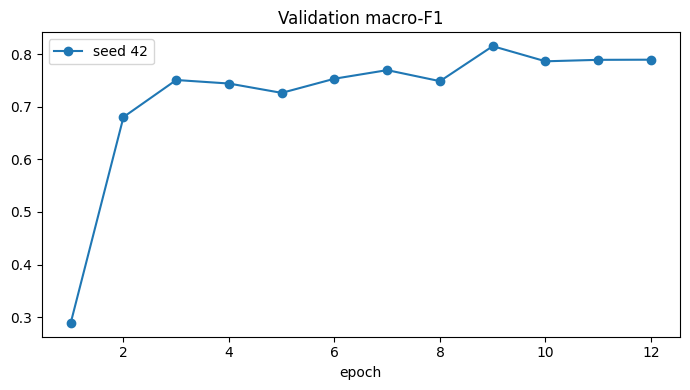

In [ ]:
plt.figure(figsize=(7,4))
for s,hist in all_hist.items():
    h=pd.DataFrame(hist); plt.plot(h.epoch,h.val_f1,"o-",label=f"seed {s}")
plt.title("Validation macro-F1"); plt.xlabel("epoch"); plt.legend(); plt.tight_layout(); plt.show()

## 15. Load best (ensemble) + TTA-averaged evaluation

The best single model is saved as `best.pt`. For evaluation/inference we average **calibrated probabilities** over (a) the ensemble members and (b) TTA views — variance reduction that improves both accuracy and reliability.

In [ ]:
best_path=os.path.join(CFG.output_dir,"best.pt"); last_path=os.path.join(CFG.output_dir,"last.pt")
shutil.copyfile(ensemble[0]["path"], best_path)
shutil.copyfile(ensemble[-1]["path"], last_path)

def load_model(ckpt_path):
    ck=torch.load(ckpt_path,map_location=DEVICE)
    m=MultiTaskMoodModel(ck["model_name"],ck["num_classes"],ck.get("num_arousal",2),ck.get("dropout",0.1),
                         CFG.mask_time_prob,CFG.mask_feature_prob)
    m.load_state_dict(ck["model_state_dict"]); m.to(DEVICE).eval()
    return (nn.DataParallel(m) if USE_DP else m)

ens_models=[load_model(e["path"]) for e in ensemble]
print("loaded ensemble:", len(ens_models), "model(s)")

def softmax_np(z): z=z-z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)

def logits_over_loader(models, loader):
    # average mood logits over ensemble members for a fixed (non-aug) loader pass
    accs=None; Y=[]
    for mi,m in enumerate(models):
        m.eval(); chunks=[]
        with torch.no_grad():
            for batch in loader:
                inp,y,ar=forward_batch(m,batch)
                with autocast(enabled=CUDA):
                    ml,_,_=m(**inp)
                chunks.append(ml.float().cpu().numpy())
                if mi==0: Y+=y.cpu().tolist()
        L=np.concatenate(chunks); accs=L if accs is None else accs+L
    return accs/len(models), np.array(Y)

def tta_probs(models, frame, T=1.0, views=1):
    # average softmax over ensemble x TTA views (augmented passes), fixed order
    ds=MoodDataset(frame,CFG,train=(views>1))   # aug only when doing >1 view
    loader=DataLoader(ds,batch_size=CFG.batch_size,shuffle=False,num_workers=CFG.num_workers,collate_fn=collate_fn,pin_memory=pin)
    acc=None; Y=None
    for v in range(max(1,views)):
        ds.aug_offset=1000+v; ds.aug_scale=1.0
        L,y=logits_over_loader(models,loader)
        p=softmax_np(L/T)
        acc=p if acc is None else acc+p
        Y=y
    return acc/max(1,views), Y

# Plain (no-TTA) val logits for temperature fitting + selection-independent calibration
val_logits,val_y=logits_over_loader(ens_models,val_loader)
print("val logits:", val_logits.shape)

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

loaded ensemble: 1 model(s)
val logits: (2661, 6)


## 16. Test evaluation — single vs TTA, per-corpus, arousal-axis

In [ ]:
target_names=[id2label[i] for i in range(NUM_CLASSES)]
# single-pass (no TTA)
test_logits,test_y=logits_over_loader(ens_models,test_loader)
pred_single=test_logits.argmax(1)
print("== Single-pass (ensemble, no TTA) ==")
print(f"acc {accuracy_score(test_y,pred_single):.4f} | macroF1 {f1_score(test_y,pred_single,average='macro',zero_division=0):.4f} | balacc {balanced_accuracy_score(test_y,pred_single):.4f}")

if CFG.use_tta:
    probs_tta,ty=tta_probs(ens_models,test_df,T=1.0,views=CFG.tta_views)
    pred_tta=probs_tta.argmax(1)
    print(f"== TTA x{CFG.tta_views} (ensemble) ==")
    print(f"acc {accuracy_score(ty,pred_tta):.4f} | macroF1 {f1_score(ty,pred_tta,average='macro',zero_division=0):.4f} | balacc {balanced_accuracy_score(ty,pred_tta):.4f}")
    test_pred=pred_tta; test_y=ty
else:
    test_pred=pred_single

print("\nClassification report (final):\n", classification_report(test_y,test_pred,target_names=target_names,digits=3,zero_division=0))

tdf=test_df.copy().reset_index(drop=True); tdf["pred"]=test_pred[:len(tdf)]; tdf["true"]=test_y[:len(tdf)]
print("Per-corpus macro-F1:")
for corp,g in tdf.groupby("corpus"):
    if len(g): print(f"  {corp:10s}: {f1_score(g.true,g.pred,average='macro',zero_division=0):.3f} (n={len(g)})")
ar={label2id[m]:AROUSAL2ID[MOOD_AROUSAL[m]] for m in target_names}
ay=np.array([ar[i] for i in test_y]); ap=np.array([ar[i] for i in test_pred])
print(f"\nArousal-axis accuracy: {accuracy_score(ay,ap):.4f}  (coarse clinical signal — the reliable output)")

== Single-pass (ensemble, no TTA) ==
acc 0.7647 | macroF1 0.7591 | balacc 0.7968
== TTA x5 (ensemble) ==
acc 0.7449 | macroF1 0.7324 | balacc 0.7731

Classification report (final):
               precision    recall  f1-score   support

        Calm      0.585     0.969     0.729        32
     Neutral      0.735     0.865     0.795       215
     Content      0.856     0.683     0.760       243
     Anxious      0.640     0.658     0.649       243
    Agitated      0.882     0.784     0.830       486
         Low      0.589     0.679     0.631       243

    accuracy                          0.745      1462
   macro avg      0.714     0.773     0.732      1462
weighted avg      0.761     0.745     0.748      1462

Per-corpus macro-F1:
  crema     : 0.599 (n=1148)
  ravdess   : 0.742 (n=208)
  savee     : 0.770 (n=105)
  tess      : 1.000 (n=1)

Arousal-axis accuracy: 0.8687  (coarse clinical signal — the reliable output)


## 17. Confusion matrix

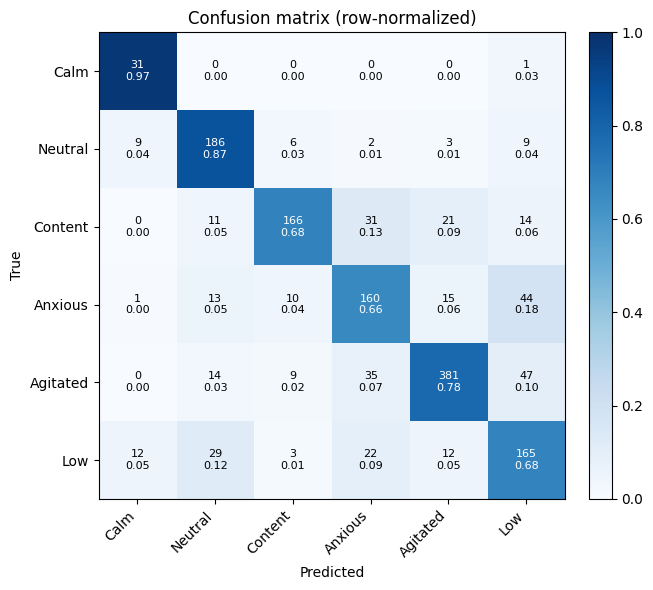

In [ ]:
cm=confusion_matrix(test_y,test_pred,labels=list(range(NUM_CLASSES))); cmn=cm/np.maximum(cm.sum(1,keepdims=True),1)
fig,ax=plt.subplots(figsize=(7,6)); im=ax.imshow(cmn,cmap="Blues",vmin=0,vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(target_names,rotation=45,ha="right"); ax.set_yticklabels(target_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion matrix (row-normalized)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j,i,f"{cm[i,j]}\n{cmn[i,j]:.2f}",ha="center",va="center",color="white" if cmn[i,j]>0.5 else "black",fontsize=8)
fig.colorbar(im,fraction=0.046,pad=0.04); plt.tight_layout(); plt.show()

## 18. Calibration — temperature scaling + ECE + reliability (fit on val)

T=1.032 | test ECE before 0.0407 | after 0.0388


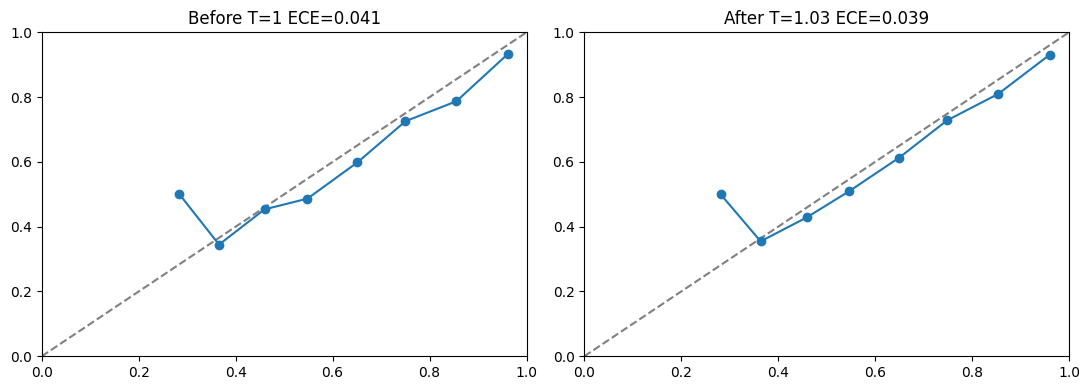

In [ ]:
def ece(probs,labels,n_bins=15):
    conf=probs.max(1); pred=probs.argmax(1); acc=(pred==labels).astype(float)
    b=np.linspace(0,1,n_bins+1); e=0.0
    for i in range(n_bins):
        m=(conf>b[i])&(conf<=b[i+1])
        if m.sum()>0: e+=abs(acc[m].mean()-conf[m].mean())*m.mean()
    return e
def fit_temperature(logits,labels):
    Lt=torch.tensor(logits,dtype=torch.float32); Yt=torch.tensor(labels,dtype=torch.long)
    T=torch.nn.Parameter(torch.ones(1)); opt=torch.optim.LBFGS([T],lr=0.05,max_iter=200); nll=nn.CrossEntropyLoss()
    def closure():
        opt.zero_grad(); l=nll(Lt/T.clamp(min=1e-2),Yt); l.backward(); return l
    opt.step(closure); return float(min(max(T.clamp(min=1e-2).item(),1e-2),100.0))

T=fit_temperature(val_logits,val_y)
# Use single-pass ensemble logits for an apples-to-apples calibration view
# (single-pass and TTA loaders share the same fixed order, so test_y aligns).
pb=softmax_np(test_logits); pa=softmax_np(test_logits/T)
yy=test_y[:len(pb)]
print(f"T={T:.3f} | test ECE before {ece(pb,yy):.4f} | after {ece(pa,yy):.4f}")
def reliability(probs,labels,ax,title):
    conf=probs.max(1); pred=probs.argmax(1); acc=(pred==labels).astype(float); b=np.linspace(0,1,11); xs,ys=[],[]
    for i in range(10):
        m=(conf>b[i])&(conf<=b[i+1])
        if m.sum()>0: xs.append(conf[m].mean()); ys.append(acc[m].mean())
    ax.plot([0,1],[0,1],"--",color="gray"); ax.plot(xs,ys,"o-"); ax.set_title(title); ax.set_xlim(0,1); ax.set_ylim(0,1)
fig,ax=plt.subplots(1,2,figsize=(11,4))
reliability(pb,yy,ax[0],f"Before T=1 ECE={ece(pb,yy):.3f}")
reliability(pa,yy,ax[1],f"After T={T:.2f} ECE={ece(pa,yy):.3f}")
plt.tight_layout(); plt.show()

## 19. Confidence threshold / abstention (clinical triage)

A monitoring system should **abstain** below a confidence τ and escalate to a clinician. This trades coverage for accuracy on the covered set.

In [ ]:
probs_final = None  # threshold table uses calibrated single-pass probabilities (stable, ordered)
# Use calibrated single-pass probabilities for a stable threshold table
pcal=softmax_np(test_logits/T); conf=pcal.max(1); pred=pcal.argmax(1); yy=test_y[:len(pcal)]
print(f"{'tau':>5}{'coverage':>10}{'acc@cov':>9}{'macroF1@cov':>12}")
for tau in [0.0,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    keep=conf>=tau
    if keep.sum()==0: print(f"{tau:5.2f}{0.0:10.3f}{'-':>9}{'-':>12}"); continue
    print(f"{tau:5.2f}{keep.mean():10.3f}{accuracy_score(yy[keep],pred[keep]):9.3f}{f1_score(yy[keep],pred[keep],average='macro',zero_division=0):12.3f}")
print("Clinical use: pick smallest tau meeting your required acc@cov; route abstentions to a clinician.")

  tau  coverage  acc@cov macroF1@cov
 0.00     1.000    0.765       0.759
 0.30     0.999    0.765       0.759
 0.40     0.977    0.774       0.767
 0.50     0.915    0.797       0.786
 0.60     0.811    0.835       0.820
 0.70     0.699    0.870       0.844
 0.80     0.588    0.897       0.863
 0.90     0.419    0.931       0.889
Clinical use: pick smallest tau meeting your required acc@cov; route abstentions to a clinician.


## 20. Error analysis

In [ ]:
err=test_df.copy().reset_index(drop=True)
err["true"]=[id2label[i] for i in test_y[:len(err)]]; err["pred"]=[id2label[i] for i in test_pred[:len(err)]]
err["correct"]=err.true==err.pred
print("Per-class accuracy:")
for m in target_names:
    s=err[err.true==m]
    if len(s): print(f"  {m:9s}: {s.correct.mean():.3f} (n={len(s)})")
print("Most-confused (true->pred):")
for (t,p),n in err[~err.correct].groupby(["true","pred"]).size().sort_values(ascending=False).head(8).items():
    print(f"  {t:9s} -> {p:9s}: {n}")

Per-class accuracy:
  Calm     : 0.969 (n=32)
  Neutral  : 0.865 (n=215)
  Content  : 0.683 (n=243)
  Anxious  : 0.658 (n=243)
  Agitated : 0.784 (n=486)
  Low      : 0.679 (n=243)
Most-confused (true->pred):
  Agitated  -> Low      : 47
  Anxious   -> Low      : 44
  Agitated  -> Anxious  : 35
  Content   -> Anxious  : 31
  Low       -> Neutral  : 29
  Low       -> Anxious  : 22
  Content   -> Agitated : 21
  Anxious   -> Agitated : 15


## 21. Inference with TTA + multi-sample voting (calibrated, abstain-aware)

In [ ]:
@torch.no_grad()
def predict_mood(path, views=None, T_=None, abstain_tau=0.5, top_k=3):
    views=views or (CFG.tta_views if CFG.use_tta else 1); T_=T_ if T_ is not None else T
    y0,_=librosa.load(path,sr=CFG.sample_rate,mono=True)
    if len(y0)>MAX_SAMPLES: y0=y0[:MAX_SAMPLES]
    prob=np.zeros(NUM_CLASSES,dtype=np.float64)
    for v in range(views):
        y=y0.copy()
        if v>0:  # augmented views for TTA
            rng=np.random.default_rng(1000+v); y=augment_waveform(y,CFG.sample_rate,CFG,rng,1.0)
        feats=feature_extractor([y.astype(np.float32)],sampling_rate=CFG.sample_rate,return_tensors="pt",
                                padding="longest",max_length=MAX_SAMPLES,truncation=True)
        inp={"input_values":feats["input_values"].to(DEVICE)}
        if "attention_mask" in feats: inp["attention_mask"]=feats["attention_mask"].to(DEVICE)
        vp=np.zeros(NUM_CLASSES,dtype=np.float64)
        for m in ens_models:
            with autocast(enabled=CUDA): ml,al,_=m(**inp)
            vp+=softmax_np(ml.float().cpu().numpy()/T_)[0]
        prob+=vp/len(ens_models)
    prob/=views
    order=prob.argsort()[::-1][:top_k]
    label=id2label[int(order[0])] if prob[order[0]]>=abstain_tau else "UNCERTAIN(abstain)"
    arousal="high" if MOOD_AROUSAL[id2label[int(order[0])]]=="high" else "low"
    return label, arousal, [(id2label[int(i)],float(prob[i])) for i in order]

print("Inference (TTA+ensemble) on held-out clips:")
for _,r in test_df.sample(min(5,len(test_df)),random_state=42).iterrows():
    lab,ar,tk=predict_mood(r["path"],abstain_tau=0.5)
    print(f"  true={r['mood']:9s} pred={lab:18s} arousal={ar:4s} | "+", ".join(f"{m}:{p:.2f}" for m,p in tk))

Inference (TTA+ensemble) on held-out clips:
  true=Anxious   pred=Anxious            arousal=high | Anxious:0.63, Low:0.33, Agitated:0.02
  true=Neutral   pred=Neutral            arousal=low  | Neutral:0.95, Low:0.04, Agitated:0.00
  true=Anxious   pred=Anxious            arousal=high | Anxious:0.54, Low:0.32, Content:0.08
  true=Neutral   pred=Neutral            arousal=low  | Neutral:0.72, Low:0.24, Anxious:0.02
  true=Agitated  pred=Agitated           arousal=high | Agitated:0.85, Content:0.12, Neutral:0.01


## 22. (Optional) Pseudo-labeling hook — the clinical domain-adaptation path

Set `CFG.pseudo_label_dir` to a folder of **unlabeled patient/clinical audio**. This generates confident pseudo-labels (≥ `pseudo_label_conf` after calibration) that you can fold into a second fine-tuning round to adapt toward the clinical domain. Off by default (no clinical data here).

In [ ]:
def generate_pseudo_labels(audio_dir, conf_thr=0.9):
    files=find_wavs(audio_dir)
    if not files:
        print("No unlabeled audio found at", repr(audio_dir), "- skipping pseudo-labeling."); return pd.DataFrame()
    out=[]
    for f in files:
        lab,ar,tk=predict_mood(str(f),abstain_tau=0.0)
        conf=tk[0][1]
        if conf>=conf_thr:
            out.append({"path":str(f),"mood":tk[0][0],"group":f"PSEUDO_{Path(f).stem}","corpus":"pseudo",
                        "label_id":label2id[tk[0][0]],"arousal_id":AROUSAL2ID[MOOD_AROUSAL[tk[0][0]]],"confidence":conf})
    pl=pd.DataFrame(out)
    print(f"Pseudo-labeled {len(pl)}/{len(files)} clips at conf>={conf_thr}.")
    return pl

if CFG.pseudo_label_dir:
    pseudo_df=generate_pseudo_labels(CFG.pseudo_label_dir, CFG.pseudo_label_conf)
    print("To use: concatenate pseudo_df into train_df and re-run training (semi-supervised round).")
else:
    print("Pseudo-labeling disabled (CFG.pseudo_label_dir empty). This is the hook to adapt to patient data.")

Pseudo-labeling disabled (CFG.pseudo_label_dir empty). This is the hook to adapt to patient data.


## 23. Export — best.pt, last.pt, label_mapping.json, hf_export/, ensemble manifest

In [ ]:
# re-save best/last with temperature embedded
for pth in [best_path,last_path]:
    ck=torch.load(pth,map_location="cpu"); ck["temperature"]=T; torch.save(ck,pth)

label_mapping={"version":3,"model_name":CFG.model_name,"label2id":label2id,
    "id2label":{str(k):v for k,v in id2label.items()},"mood_states":target_names,
    "mood_arousal":MOOD_AROUSAL,"arousal2id":AROUSAL2ID,"emotion_to_mood":EMOTION_TO_MOOD,
    "sample_rate":CFG.sample_rate,"max_duration_sec":CFG.max_duration_sec,"max_samples":MAX_SAMPLES,
    "temperature":T,"tta_views":CFG.tta_views if CFG.use_tta else 1,"dropout":CFG.dropout,
    "num_arousal":NUM_AROUSAL,"holdout_corpus":CFG.holdout_corpus,"merge_calm_into_neutral":CFG.merge_calm_into_neutral,
    "smoke_test_mode":SMOKE,"architecture":"MultiTaskMoodModel(WavLM + attentive-pool + mood&arousal heads)"}
mapping_path=os.path.join(CFG.output_dir,"label_mapping.json")
with open(mapping_path,"w") as fh: json.dump(label_mapping,fh,indent=2)

hf_dir=os.path.join(CFG.output_dir,"hf_export"); os.makedirs(hf_dir,exist_ok=True)
try:
    unwrap(model).backbone.save_pretrained(hf_dir)
    feature_extractor.save_pretrained(hf_dir)
    torch.save({"mood_head":unwrap(model).mood_head.state_dict(),
                "arousal_head":unwrap(model).arousal_head.state_dict(),
                "pool":unwrap(model).pool.state_dict()}, os.path.join(hf_dir,"heads.pt"))
    with open(os.path.join(hf_dir,"heads_config.json"),"w") as fh:
        json.dump({"num_classes":NUM_CLASSES,"num_arousal":NUM_AROUSAL,"dropout":CFG.dropout,
                   "hidden_size":unwrap(model).backbone.config.hidden_size},fh,indent=2)
    print("hf_export written:", hf_dir)
except Exception as e:
    print("hf_export warning:", e)

manifest={"members":[{"seed":e["seed"],"file":os.path.basename(e["path"]),"val_macro_f1":e["val_f1"]} for e in ensemble],
          "temperature":T,"primary":"best.pt","note":"average calibrated softmax over members for ensemble inference"}
with open(os.path.join(CFG.output_dir,"ensemble_manifest.json"),"w") as fh: json.dump(manifest,fh,indent=2)

for f in sorted(glob.glob(os.path.join(CFG.output_dir,"*"))):
    print(("  %s (%.2f MB)"%(f,os.path.getsize(f)/1e6)) if os.path.isfile(f) else f"  {f}/")
for req in [best_path,last_path,mapping_path]: assert os.path.exists(req), f"missing {req}"
print("Required artifacts present.")
if SMOKE: print("*** Synthetic smoke-test artifacts — NOT clinically valid. ***")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

hf_export written: outputs/hf_export
  outputs/best.pt (380.00 MB)
  outputs/best_seed42.pt (380.02 MB)
  outputs/ensemble_manifest.json (0.00 MB)
  outputs/hf_export/
  outputs/label_mapping.json (0.00 MB)
  outputs/last.pt (380.00 MB)
Required artifacts present.


## 24. Reload verification (rebuild multi-task model + ensemble-averaging loader)

In [ ]:
def load_ensemble_from_manifest(output_dir="outputs"):
    with open(os.path.join(output_dir,"ensemble_manifest.json")) as fh: man=json.load(fh)
    models=[]
    for m in man["members"]:
        p=os.path.join(output_dir,m["file"])
        if os.path.exists(p): models.append(load_model(p))
    if not models: models=[load_model(os.path.join(output_dir,"best.pt"))]
    return models, man.get("temperature",1.0)
_mods,_T=load_ensemble_from_manifest(CFG.output_dir)
print("reloaded ensemble:", len(_mods), "| temperature:", round(_T,3))
del _mods; gc.collect()
if CUDA: torch.cuda.empty_cache()

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

reloaded ensemble: 1 | temperature: 1.032


## 25. Package into downloadable ZIP (best.pt, last.pt, label_mapping.json, hf_export/, manifest)

In [ ]:
def build_model_zip(output_dir="outputs", zip_name="model_package.zip"):
    out=Path(output_dir); out.mkdir(exist_ok=True)
    best=out/"best.pt"; last=out/"last.pt"; mapping=out/"label_mapping.json"; hf=out/"hf_export"
    if not hf.exists() or not any(hf.iterdir()):
        try:
            unwrap(model).backbone.save_pretrained(str(hf)); feature_extractor.save_pretrained(str(hf))
            torch.save({"mood_head":unwrap(model).mood_head.state_dict(),
                        "arousal_head":unwrap(model).arousal_head.state_dict(),
                        "pool":unwrap(model).pool.state_dict()}, str(hf/"heads.pt"))
            print("hf_export regenerated.")
        except Exception as e: print("WARNING hf_export:", e)
    required={"best.pt":best,"last.pt":last,"label_mapping.json":mapping}
    missing=[k for k,p in required.items() if not p.exists()]
    if missing: raise FileNotFoundError(f"Missing: {missing}")
    zp=out/zip_name
    if zp.exists(): zp.unlink()
    written=set()
    def _write(z, path, arc):
        if arc in written: return
        z.write(path, arcname=arc); written.add(arc)
    with zipfile.ZipFile(zp,"w",zipfile.ZIP_DEFLATED) as z:
        for name,p in required.items(): _write(z,p,name)
        man=out/"ensemble_manifest.json"
        if man.exists(): _write(z,man,"ensemble_manifest.json")
        for e in ensemble:
            sp=Path(e["path"])
            if sp.exists(): _write(z,sp,sp.name)
        if hf.exists():
            for root,_,files in os.walk(hf):
                for fn in files:
                    full=Path(root)/fn; _write(z,full,str(full.relative_to(out)))
    return zp
zip_path=build_model_zip(CFG.output_dir,"model_package.zip")
print("\nFINAL ZIP:", str(zip_path)); print(f"ZIP size: {os.path.getsize(zip_path)/1e6:.2f} MB")
with zipfile.ZipFile(zip_path) as z:
    for info in z.infolist(): print(f"  {info.filename:40s} {info.file_size/1e6:7.2f} MB")
print("\nDownload from the Kaggle 'Output' panel:", str(zip_path))


FINAL ZIP: outputs/model_package.zip
ZIP size: 1390.99 MB
  best.pt                                   380.00 MB
  last.pt                                   380.00 MB
  label_mapping.json                          0.00 MB
  ensemble_manifest.json                      0.00 MB
  best_seed42.pt                            380.02 MB
  hf_export/model.safetensors               377.56 MB
  hf_export/heads.pt                          2.39 MB
  hf_export/heads_config.json                 0.00 MB
  hf_export/config.json                       0.00 MB
  hf_export/preprocessor_config.json          0.00 MB

Download from the Kaggle 'Output' panel: outputs/model_package.zip


In [ ]:
from pathlib import Path

print("outputs exists:", Path("outputs").exists())

for p in Path("outputs").rglob("*"):
    print(p)

outputs exists: True
outputs/ensemble_manifest.json
outputs/hf_export
outputs/model_package.zip
outputs/best.pt
outputs/label_mapping.json
outputs/last.pt
outputs/best_seed42.pt
outputs/hf_export/model.safetensors
outputs/hf_export/heads.pt
outputs/hf_export/heads_config.json
outputs/hf_export/config.json
outputs/hf_export/preprocessor_config.json


In [ ]:
from IPython.display import FileLink

FileLink("outputs/model_package.zip")

/content/outputs/model_package.zip

## E. Summary & honest expectations

**What v3 changes and why:** a **multi-task** model that learns the reliable arousal axis alongside 6-way mood; **class-balanced focal** + tempered sampling for principled imbalance handling; **domain-shift augmentation** (telephony/reverb/noise) on a **curriculum**; **supervised-contrastive** metric learning to sharpen valence-separated embeddings; **TTA + ensemble** averaging for variance reduction; **temperature calibration + abstention** for clinically trustworthy decisions; **per-corpus + leave-one-corpus-out** evaluation for honest generalization; and a **pseudo-labeling hook** for adapting to real patient data.

**Realistic ceilings (valid, speaker-disjoint 6-way):** ~75% is attainable; ~80% is the optimistic edge and partly reflects easy corpora; **~85% is not achievable validly** on these acted datasets and would signal leakage — pursue 85%+ only on the **coarse arousal/distress** output, which is also the more clinically useful signal.

**The honest bottom line:** the limiting factor is the *data* (acted speech, ambiguous perceived labels) and the *unmeasured clinical domain shift*, not model capacity. The single most valuable next step for a real Alzheimer's platform is **not** a bigger model — it is acquiring clinician-labeled patient speech and using the pseudo-labeling/domain-adaptation path, then evaluating with calibration, abstention, and cross-population fairness. No configuration here is perfect or deployment-ready.